In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
print("Размер:", df.shape)
display(df.head())
print("\nТипы данных:")
print(df.dtypes)
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nОписание:")
display(df.describe())

Размер: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Типы данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Пропущенные значения:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Описание:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


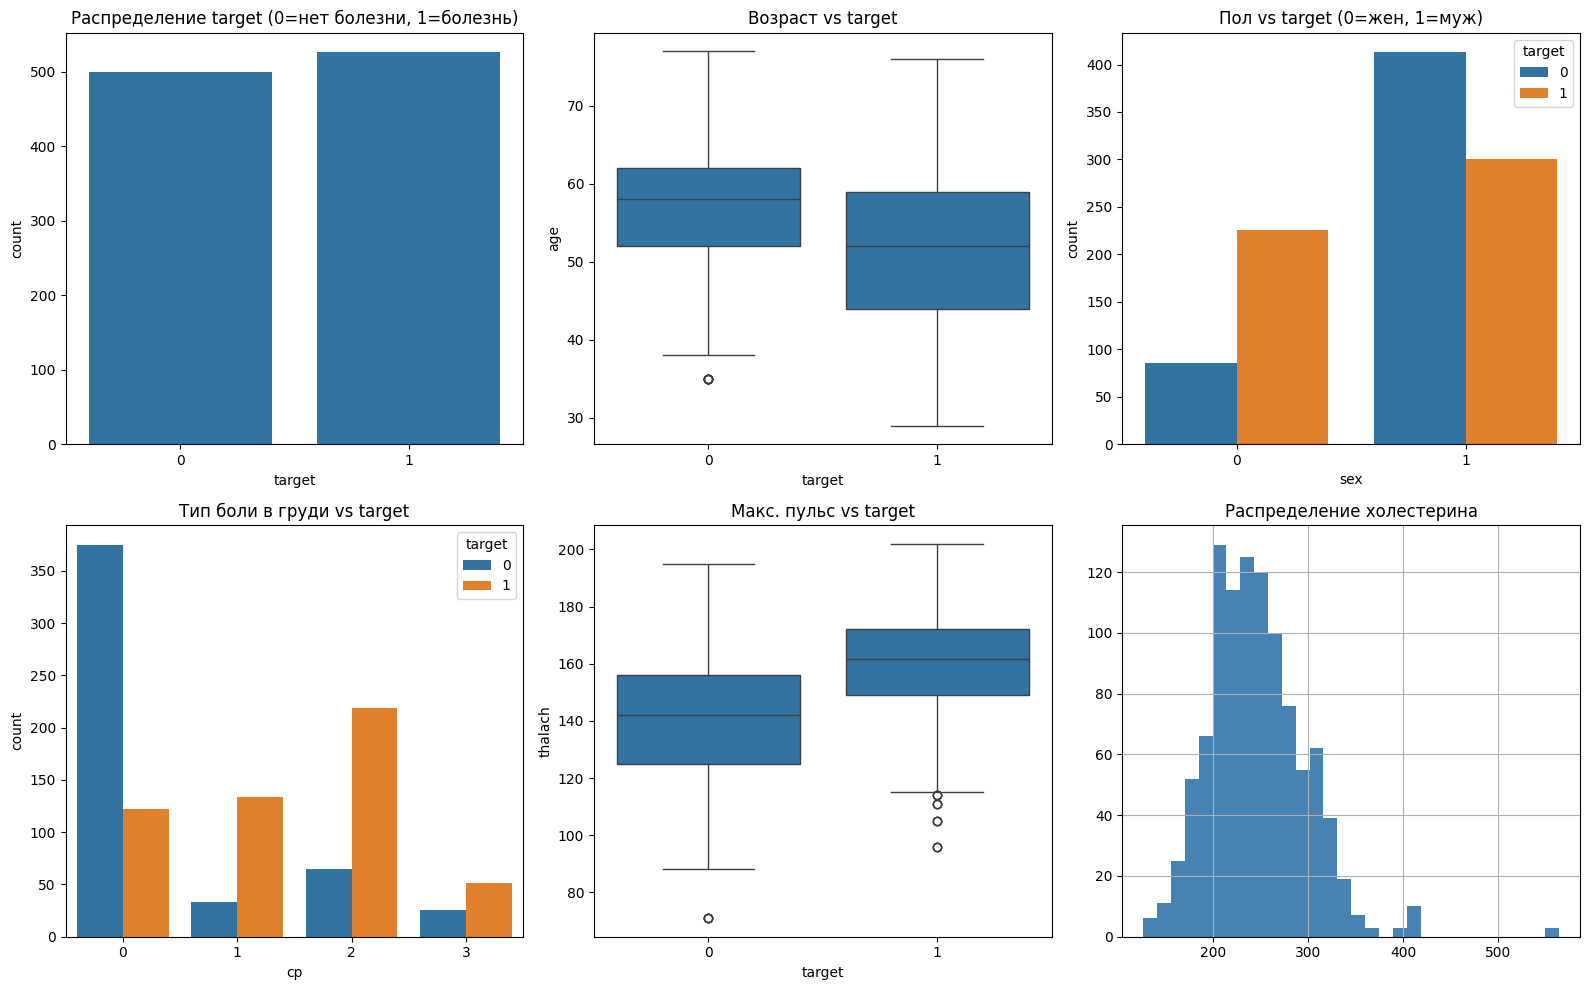

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Распределение целевого признака
sns.countplot(data=df, x='target', ax=axes[0,0])
axes[0,0].set_title('Распределение target (0=нет болезни, 1=болезнь)')

# Возраст vs target
sns.boxplot(data=df, x='target', y='age', ax=axes[0,1])
axes[0,1].set_title('Возраст vs target')

# Пол vs target
sns.countplot(data=df, x='sex', hue='target', ax=axes[0,2])
axes[0,2].set_title('Пол vs target (0=жен, 1=муж)')

# Тип боли в груди vs target
sns.countplot(data=df, x='cp', hue='target', ax=axes[1,0])
axes[1,0].set_title('Тип боли в груди vs target')

# Максимальный пульс vs target
sns.boxplot(data=df, x='target', y='thalach', ax=axes[1,1])
axes[1,1].set_title('Макс. пульс vs target')

# Холестерин
df['chol'].hist(bins=30, ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Распределение холестерина')

plt.tight_layout()
plt.show()

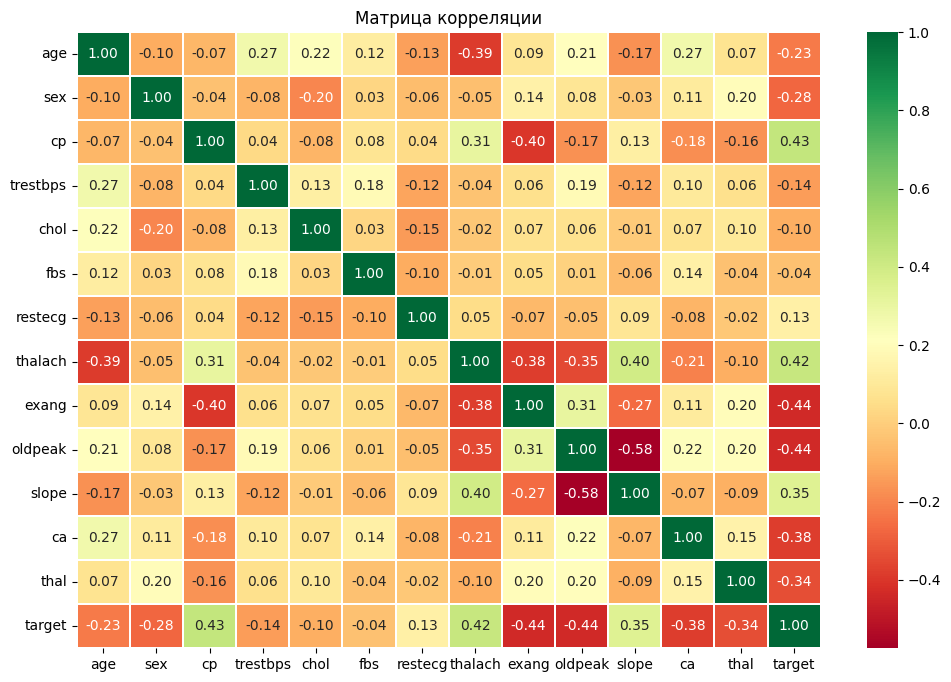

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.2)
plt.title('Матрица корреляции')
plt.show()

In [5]:
# Все признаки уже числовые, пропусков нет — чистка не нужна
# Удаляем дубликаты
df = df.drop_duplicates()
print("Размер после удаления дубликатов:", df.shape)

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train_s.shape, "  Test:", X_test_s.shape)

Размер после удаления дубликатов: (302, 14)
Train: (241, 13)   Test: (61, 13)


In [6]:
class MyKNN:
    """k ближайших соседей — собственная реализация."""

    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric  # 'euclidean' или 'manhattan'

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, a, b):
        if self.metric == 'manhattan':
            return np.sum(np.abs(a - b), axis=1)
        return np.sqrt(np.sum((a - b) ** 2, axis=1))

    def predict(self, X):
        X = np.array(X)
        preds = []
        for x in X:
            dists = self._distance(self.X_train, x)
            nn_idx = np.argsort(dists)[:self.k]
            nn_labels = self.y_train[nn_idx]
            preds.append(np.bincount(nn_labels).argmax())
        return np.array(preds)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

In [7]:
k_values = [3, 5, 7, 9, 11, 15]
metrics = ['euclidean', 'manhattan']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_acc = 0
best_k, best_metric = 5, 'euclidean'

for k in k_values:
    for m in metrics:
        fold_accs = []
        for train_idx, val_idx in kf.split(X_train_s):
            Xtr, Xval = X_train_s[train_idx], X_train_s[val_idx]
            ytr, yval = y_train.values[train_idx], y_train.values[val_idx]
            model = MyKNN(k=k, metric=m)
            model.fit(Xtr, ytr)
            fold_accs.append(model.score(Xval, yval))
        mean_acc = np.mean(fold_accs)
        if mean_acc > best_acc:
            best_acc = mean_acc
            best_k, best_metric = k, m

print(f"Лучшие параметры MyKNN: k={best_k}, metric={best_metric}, CV accuracy={best_acc:.4f}")

my_knn = MyKNN(k=best_k, metric=best_metric)
my_knn.fit(X_train_s, y_train.values)
test_acc_myknn = my_knn.score(X_test_s, y_test.values)
print(f"Test accuracy MyKNN: {test_acc_myknn:.4f}")

Лучшие параметры MyKNN: k=11, metric=euclidean, CV accuracy=0.8339
Test accuracy MyKNN: 0.7869


In [8]:
class MyGaussianNB:
    """Gaussian Naive Bayes — собственная реализация."""

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.stds_ = {}
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(X)
            self.means_[c] = Xc.mean(axis=0)
            self.stds_[c] = Xc.std(axis=0) + 1e-9
        return self

    def _log_likelihood(self, x, c):
        mu, sigma = self.means_[c], self.stds_[c]
        return np.sum(-np.log(sigma) - 0.5 * ((x - mu) / sigma) ** 2)

    def predict(self, X):
        X = np.array(X)
        preds = []
        for x in X:
            scores = {c: np.log(self.priors_[c]) + self._log_likelihood(x, c)
                      for c in self.classes_}
            preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

In [9]:
# sklearn модели с GridSearchCV
sklearn_models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000),
        {'C': [0.01, 0.1, 1, 10, 100]}
    ),
    'SVM': (
        SVC(),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    ),
    'KNN (sklearn)': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
    ),
    'Naive Bayes (sklearn)': (
        GaussianNB(),
        {}
    ),
}

trained_models = {}
results = {}

for name, (model, params) in sklearn_models.items():
    if params:
        gs = GridSearchCV(model, params, cv=5, scoring='accuracy')
        gs.fit(X_train_s, y_train)
        best_model = gs.best_estimator_
        print(f"{name}: лучшие параметры = {gs.best_params_}")
    else:
        best_model = model.fit(X_train_s, y_train)

    train_acc = accuracy_score(y_train, best_model.predict(X_train_s))
    test_acc  = accuracy_score(y_test,  best_model.predict(X_test_s))
    trained_models[name] = best_model
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc}
    print(f"  Train: {train_acc:.4f}  Test: {test_acc:.4f}")

# Добавляем свои модели
my_nb = MyGaussianNB()
my_nb.fit(X_train_s, y_train.values)
results['MyKNN']    = {'train_acc': my_knn.score(X_train_s, y_train.values),
                       'test_acc':  test_acc_myknn}
results['MyNaiveBayes'] = {'train_acc': my_nb.score(X_train_s, y_train.values),
                            'test_acc':  my_nb.score(X_test_s, y_test.values)}

Logistic Regression: лучшие параметры = {'C': 0.01}
  Train: 0.8423  Test: 0.8033
SVM: лучшие параметры = {'C': 0.1, 'kernel': 'linear'}
  Train: 0.8548  Test: 0.8033
KNN (sklearn): лучшие параметры = {'metric': 'euclidean', 'n_neighbors': 9}
  Train: 0.8963  Test: 0.8033
Decision Tree: лучшие параметры = {'max_depth': 3, 'min_samples_split': 2}
  Train: 0.8589  Test: 0.8033
  Train: 0.8299  Test: 0.7869



=== Сравнение моделей ===


,train_acc,test_acc
Logistic Regression,0.8423,0.8033
SVM,0.8548,0.8033
KNN (sklearn),0.8963,0.8033
Decision Tree,0.8589,0.8033
Naive Bayes (sklearn),0.8299,0.7869
MyKNN,0.8672,0.7869
MyNaiveBayes,0.8299,0.7869


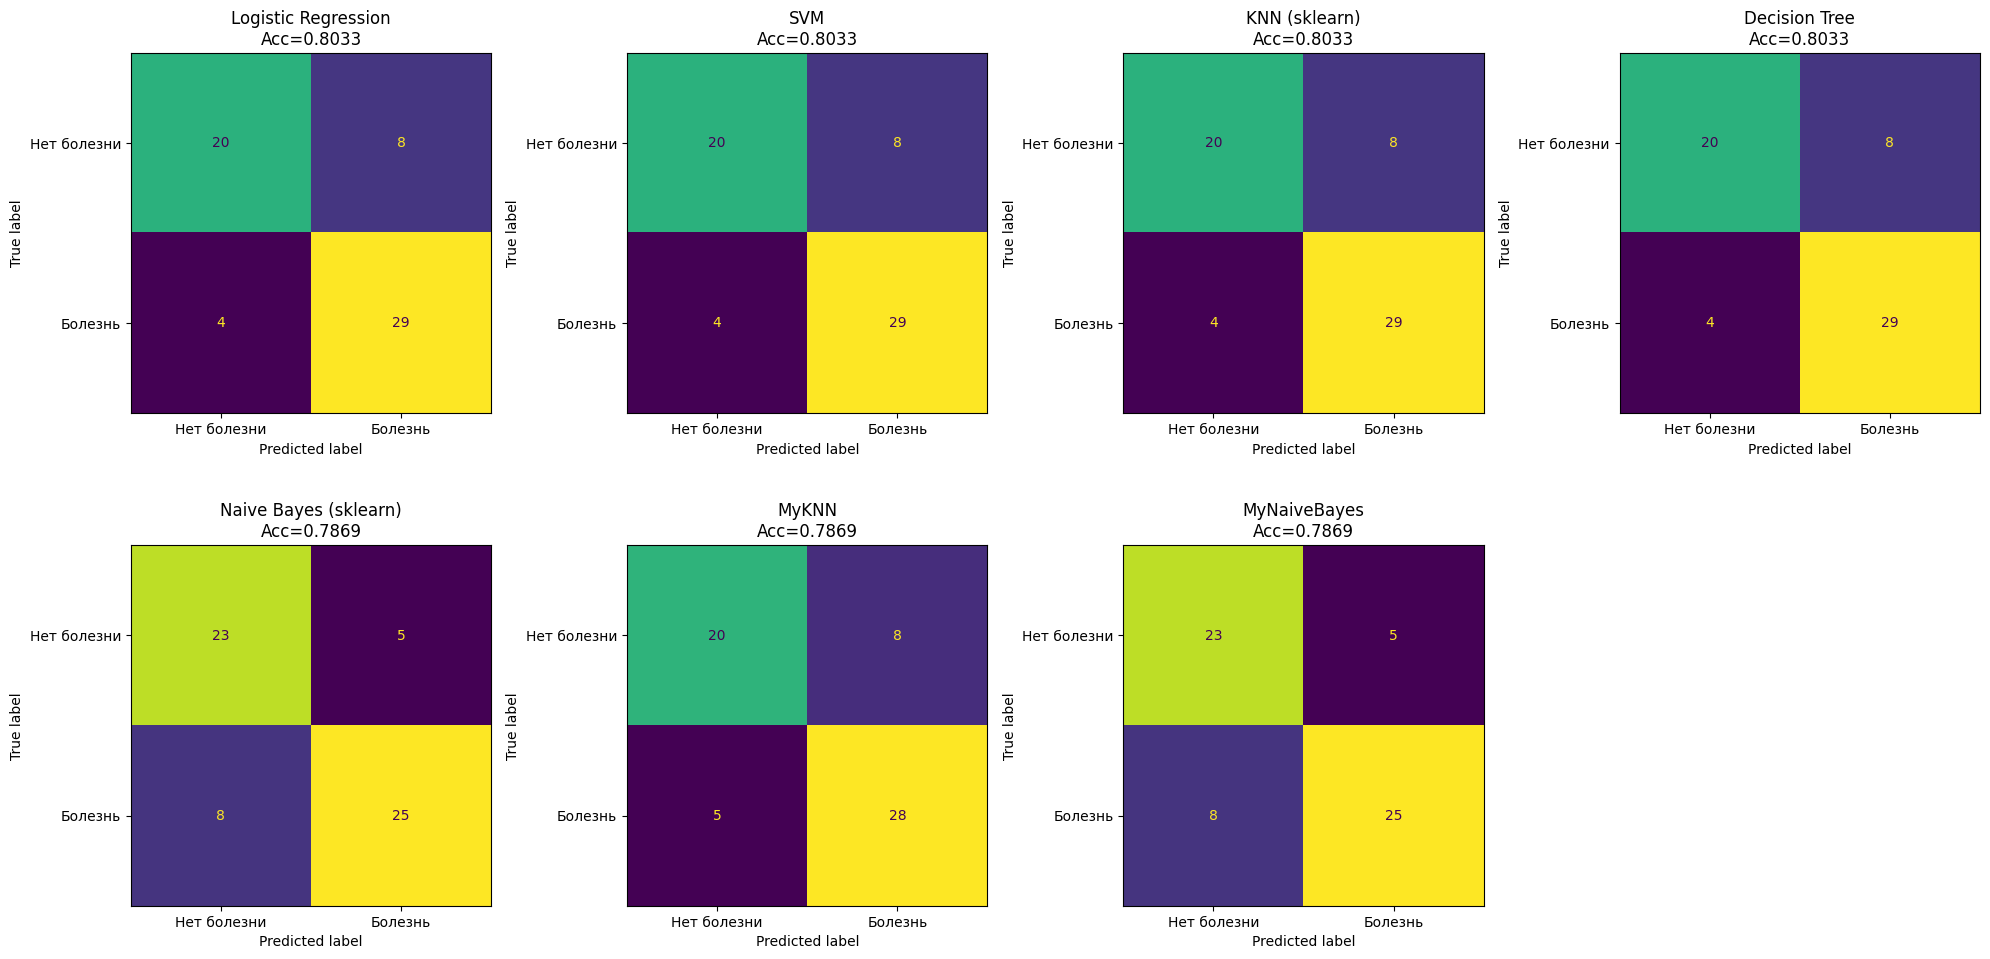

In [10]:
# Таблица сравнения
results_df = pd.DataFrame(results).T
print("\n=== Сравнение моделей ===")
display(results_df.round(4))

# Confusion matrices
all_models_for_cm = {**trained_models,
                     'MyKNN': my_knn,
                     'MyNaiveBayes': my_nb}

n = len(all_models_for_cm)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(all_models_for_cm.items()):
    y_pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Нет болезни', 'Болезнь'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f'{name}\nAcc={accuracy_score(y_test, y_pred):.4f}')

# Скрываем лишние оси
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()